# 03 Perturbed Echo

Insert a local perturbation `W` between `U` and `U dagger`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cirq
import cirq_google as cg

In [2]:
def simple_random_circuit(qubits, depth, seed=0):
    """Creating a simple random circuit """

    if not num_qubits % 2 == 0:
        return print("Total number of qubits has to be even") 

    rng = np.random.default_rng(seed)
    powers = [0.25, 0.5, 0.75, -0.25, -0.5, -0.75]
    single_qubit_gate = [cirq.X, cirq.Y, cirq.Z]
    c = cirq.Circuit()

    for layer in range(depth):
        for q in qubits:
            gate = rng.choice(single_qubit_gate)
            power = rng.choice(powers)
            c.append(gate(q)**power)

        # Entangling layer: even bonds
        for i in range(0, len(qubits) - 1, 2):
            c.append(cirq.CZ(qubits[i], qubits[i + 1]))

        for q in qubits:
            gate = rng.choice(single_qubit_gate)
            power = rng.choice(powers)
            c.append(gate(q)**power)
            
        # Entangling layer: odd bonds
        for i in range(1, len(qubits) - 1, 2):
            c.append(cirq.CZ(qubits[i], qubits[i + 1]))
    return c

In [3]:
def noiseless_echo_circuit(qubits, depth, probe, seed):
    if not num_qubits % 2 == 0:
        return print("Total number of qubits has to be even") 

    #Initializing the circuit
    c = cirq.Circuit(
        cirq.X(qubits[probe]), # Making probe = 1
        [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == probe],
        )
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    U_t_dagger = cirq.inverse(U_t)
    c.append(U_t_dagger)
    c.append(cirq.measure(qubits[probe], key="z"))
    
    results = sampler.run(c, repetitions=1000)
    counts = results.measurements["z"]
    return counts

def noiseless_perturbed_echo_circuit(qubits, depth, probe, pert, seed):

    if not num_qubits % 2 == 0:
        return print("Total number of qubits has to be even") 
    
    
    #Initializing the circuit
    c = cirq.Circuit(
        cirq.X(qubits[probe]), # Making probe = 1
        [cirq.YPowGate(exponent=0.5)(qubits[j]) for j in range(num_qubits) if not j == probe],
        )
    
    U_t = simple_random_circuit(qubits, depth, seed)
    c.append(U_t)
    
    U_t_dagger = cirq.inverse(U_t)

    #Perturbation
    c.append(cirq.measure(qubits[pert], key="z_p"))

    c.append(U_t_dagger)
    c.append(cirq.measure(qubits[probe], key="z"))
    
    results = sampler.run(c, repetitions=1000)
    counts = results.measurements["z"]
    return counts

In [8]:
num_qubits = 6
qubits = cirq.LineQubit.range(num_qubits)
depths = 15
sampler = cirq.Simulator()
seed = 3
rnd_instances = 20

count_avg_un_p_s = [np.zeros(depths) for i in range(num_qubits-1)]
count_avg_p_s = [np.zeros(depths) for i in range(num_qubits-1)]

for probe in range(1, num_qubits):
    count_avg_un_p, count_avg_p = np.zeros(depths), np.zeros(depths)
    for layer in range(depths):
        count_un_p, count_p = 0., 0.
        for seed in range(rnd_instances):
            count_un_p += np.mean(noiseless_echo_circuit(qubits, layer, probe, seed), axis = 0)[0]
            count_p += np.mean(noiseless_perturbed_echo_circuit(qubits, layer, probe, pert, seed), axis = 0)[0]

        count_un_p /= rnd_instances
        count_p /= rnd_instances
        count_avg_un_p[layer] = count_un_p
        count_avg_p[layer] = count_p
    count_avg_un_p_s[probe-1] = count_avg_un_p
    count_avg_p_s[probe-1] = count_avg_p

(0.4, 1.05)

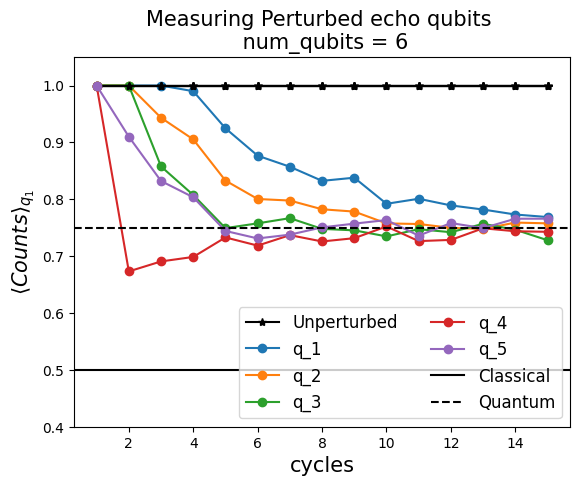

In [20]:
fontsize_plot = 15
for probe in range(num_qubits-1):
    if probe ==0:
        plt.plot(range(1,depths+1), count_avg_un_p_s[probe], "-*", color="black", label="Unperturbed")
    else:
        plt.plot(range(1,depths+1), count_avg_un_p_s[probe], "-*", color="black")
    plt.plot(range(1,depths+1), count_avg_p_s[probe], "-o", label=f"q_{probe+1}")

plt.axhline(1/2, label= "Classical", color = "black")
plt.axhline(3/4, linestyle = "--",label= "Quantum", color = "black")
plt.title(f"Measuring Perturbed echo qubits \n num_qubits = {num_qubits}", fontsize= fontsize_plot)
plt.xlabel("cycles", fontsize= fontsize_plot)
plt.ylabel(r"$\langle Counts \rangle_{q_{1}}$", fontsize= fontsize_plot)
plt.legend(fontsize =fontsize_plot-3, loc="lower right", ncol=2)
plt.ylim(0.4, 1.05)

In [ ]:
import pathlib, sys
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
from src.analysis import sweep_perturbation_strength
from src.circuits import make_line_qubits
from src.plotting import plot_echo_signal_vs_theta

In [ ]:
qubits = make_line_qubits(3)
df = sweep_perturbation_strength(qubits, depth=4, theta_values=np.linspace(0, np.pi, 11))
df

In [ ]:
plot_echo_signal_vs_theta(df);